# 2.2: Introduction to Matplotlib

Data visualisation is useful for exploring data and communicating things that you discover. A graph comparing two variables can give a quick, intuitive understanding of how the variables are related and so help to direct your research.
A graphical representation of the relationships present in data is often invaluable to explain and support the conclusions of your research.

In this notebook, we will introduce the popular Python library `matplotlib` and provide a conceptual understanding of how it works. Matplotlib is a huge library and allows very fine control over the appearance of plots produced. You should expect to refer regularly to the official <a target="_blank" href="https://matplotlib.org/stable/index.html">documentation</a> to work out how to achieve exactly the output you want rather than trying to memorise every possible parameter of every function in advance.
The documentation is extensive, searchable, and includes a large number of helpful <a target="_blank" href="https://matplotlib.org/stable/gallery/index.html">examples</a> and <a target="_blank" href="https://matplotlib.org/stable/tutorials/index.html">tutorials</a>. However, it isn't perfect, and it can sometimes be difficult to find out how the particular thing you may be interested in works.

In order to begin plotting, we need to import `pyplot` from Matplotlib. Jupyter Notebooks support in-line plotting, where plots will appear below the corresponding code cell, but to make use of this, we need to tell Matplotlib to plot in-line as follows:

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline

We will also occasionally use NumPy and Pandas in this lesson, so we need to import these as well. Note that Pandas is not generally required to use Matplotlib, but since Pandas is so useful for storing and manipulating the data we want to represent, it is common that they are used together.

In [2]:
import numpy as np
import pandas as pd

Our first example shows how to create a simple plot containing two lines.
We will explore all of the methods used in more detail below.

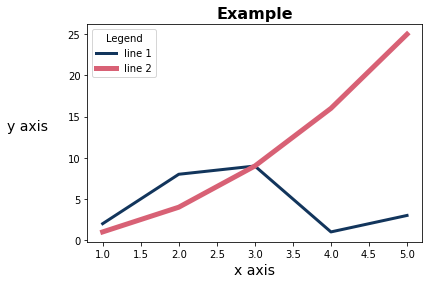

In [3]:
fig, ax = plt.subplots()
ax.plot([1,2,3,4,5], [2,8,9,1,3], label='line 1', color='#12355C', linewidth=3)
ax.plot([1,2,3,4,5], [1,4,9,16,25], label='line 2', color='#D86175', linewidth=5)
ax.set_xlabel('x axis', fontsize=14)
ax.set_ylabel('y axis', fontsize=14, rotation=0, labelpad=40)
ax.set_title("Example", fontsize=16, fontweight='bold')
ax.legend(title='Legend')

The first line of this example, `fig, ax = plt.subplots()`, creates a new figure for us to work with.

The simplest type of plot to create is a line chart.
The method `plot()` takes the values for the x axis (the horizontal axis), followed by the values for the y axis (the vertical axis).
The number of values must match since it's not possible to plot data with more x than y values, or vice versa.

Inspecting this first example, you can see the functions used to set labels for the x axis and y axis and to set the title and create a legend.
The values for the x axis and y axis are automatically set as appropriate for the data.
The colours of the two lines have also been chosen automatically.
It is possible to override any of these choices.

If you are programming in an environment where in-line plotting is not supported, it is necessary to call the function `plt.show()` to make your plot appear.
This function causes all open figures to be displayed. However, since we are able to plot inline in this notebook, we do not need to use it.

## Saving plots as image files

A figure can be saved using the method `savefig()` with a filename:

In [ ]:
fig.savefig('testfig.png')

Here the filename is `testfig.png`, and a file with this name should appear in the same directory as this notebook once you've run the cell. Running it again will overwrite the file, so take care, for example, when you're preparing figures in Python for a report.

The format of the figure is automatically determined by the extension used in the file name, which in this case was png. It is also possible to specify the format using the `format` parameter, but note that the file name will be whatever is specified, so these should match.

The resolution of the saved figure can be changed using the parameter `dpi` (i.e. dots per inch).

In [ ]:
fig.savefig('testfig.pdf',format='pdf',dpi=200)

The default resolution inherits from the figure (typically 100 DPI), which is quite low (but equally, the file size will be relatively small); a reasonable resolution is about 300, and a relatively high resolution is 600, although it will depend on how big your figure is and whether you scale it up or down in size.

## The most important Matplotlib objects

To use Matplotlib effectively, it's important to understand the different parts of a plot and the terms used for each of these.

### Figure
The very first line in the above example is `fig, ax = plt.subplots()`.
The variable `fig` holds the **figure** which was returned by the `subplots()` function.
Think of the figure as the container for everything else, the whole image being drawn by Matplotlib.
As usual, the choice of variable name is not important, but it happens that fig is very common, including in the official documentation.
The size of the figure is set automatically, but can be modified by passing a tuple of the width and height in inches to the ``figsize``keyword parameter when ``subplots()`` is called.
The next example illustrates this.

### Axes
In our example, the variable `ax` holds an **Axes**, also returned by the `subplots()` function.
An Axes is essentially a single plot and contains all the components of that plot.
An Axes is contained within a figure; a figure typically contains at least one Axes and could contain many, as in the following example.

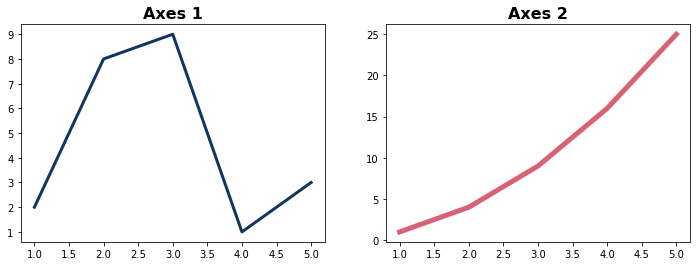

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].set_title("Axes 1", fontsize=16, fontweight='bold')
axs[0].plot([1,2,3,4,5], [2,8,9,1,3], color='#12355C', linewidth=3)
axs[1].set_title("Axes 2", fontsize=16, fontweight='bold')
axs[1].plot([1,2,3,4,5], [1,4,9,16,25], color='#D86175', linewidth=5)

In this example, we passed parameters to the ``subplots()`` function to say that we want a 1 by 2 grid of Axes.
A single figure is returned, but now a NumPy array containing two Axes objects is returned.
The two Axes both belong to the same figure.
Each individual Axes is accessed with its index.
A title and legend belong to an Axes, and the data is plotted onto an Axes.

### Axis
An axis is not the same as an Axes.
This is slightly confusing terminology, but it's worth understanding the distinction from the beginning.
An axis is a single number line, such as the x axis, or the y axis.
Each axis has a number of **ticks** and **tick labels** that show the values represented by the axis.
An axis may also have a label.
An Axes contains two axis objects (or three, for 3D plotting).


## Plotting
We've already seen how to plot a line comparing two variables, and Matplotlib is capable of drawing many other types of plots as well.
For every type of plot there are numerous possibilities for customisation.
In this lesson, we will briefly describe a variety of plots, and you will have a chance to further explore the relevant methods in the exercises that follow.

### plot()
The first two parameters passed into the ``plot()`` method are the x and y data.
The data is expected to be in the form of a list or numpy array, and there must be the same number of data points for the x and y data.
It's possible to draw several lines on an Axes with only one call to the ``plot()`` method, by simply passing in more x and y data, but there is no particular benefit to doing this.

The colour and style of the line can be set when plotting either by using keyword arguments or in a shorthand formatting string.
Using the shorthand string supports fewer options but is quick and convenient for those it does support.
Alternatively, the ``plot()`` method returns a list of the line objects it has drawn, and there are methods on the line object for modifying how it's displayed.

The following example shows three ways of specifying red dashed lines with circles at the data points.
Choose the one that you like best.
There are a huge number of formatting possibilities, but you'll probably find you use just a few favourite styles most of the time.

It's common in Matplotlib that there are multiple ways of achieving the same thing.
This can be a little confusing at first, but it adds a lot of convenience once you're used to it.



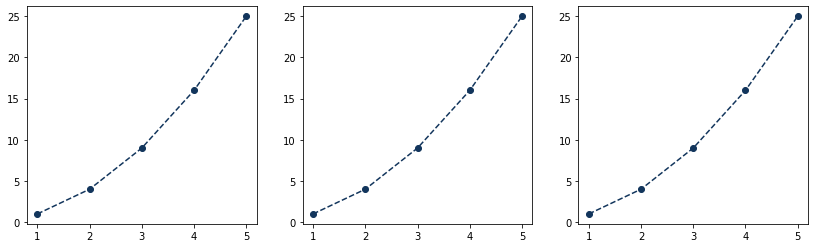

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4))
# shorthand formatting string: marker linestyle color
axs[0].plot([1,2,3,4,5], [1,4,9,16,25], 'o--', color='#12355C')
# keyword arguments
axs[1].plot([1,2,3,4,5], [1,4,9,16,25], color='#12355C', linestyle='--', marker='o')
# methods on the line object
lines = axs[2].plot([1,2,3,4,5], [1,4,9,16,25])
lines[0].set_color('#12355C')
lines[0].set_linestyle('--')
lines[0].set_marker('o')

If you have data in a Pandas DataFrame, a slightly different way of using the ``plot()`` method is convenient.
In this case, the first two arguments are the column names for the x and y data, the third argument is the DataFrame containing the data.

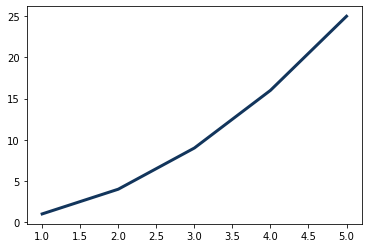

In [6]:
squares = pd.DataFrame({
    "x data": [1,2,3,4,5],
    "y data": [1,4,9,16,25]
})
fig, ax = plt.subplots()
ax.plot('x data', 'y data', data=squares, color='#12355C', linewidth=3)

Pandas DataFrames also inherit some of the Matplotlib plotting functionality, so you can plot directly from a DataFrame:

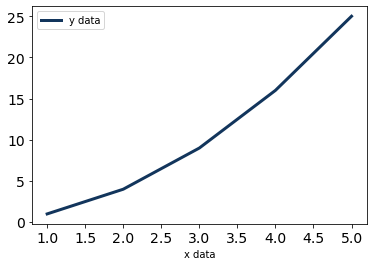

In [ ]:
ax = squares.plot('x data', 'y data', fontsize=14, color='#12355C', linewidth=3)

In the figure above, if we had more data points, then the line would look smoother.
To draw mathematical functions, it's often convenient to use numpy to generate data to plot.
This is where the NumPy function `linspace()` is very useful.
Remember that NumPy is great for applying the same function to a collection of numbers, so you could use thousands or even tens of thousands of points within your plot to make your line really smooth (but this may be unnecessary, for example, a straight line only really needs two points – the start and end).
In the example below, we generate data by creating a NumPy array of values and then calculating the square of each of them. 

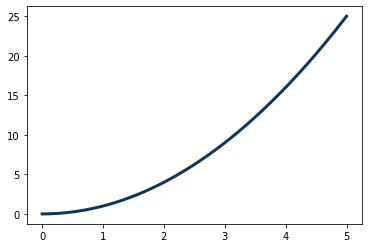

In [7]:
fig, ax = plt.subplots()
x = np.linspace(0.0, 5.0, 500)  # 500 equally spaced values between 0 and 5
y = np.square(x)  # calculate the square of every value
ax.plot(x, y, color='#12355C', linewidth=3)

### scatter()
Similarly to ``plot()``, the first two arguments we pass to the ``scatter()`` method for drawing a scatter plot are the x and y data.

The size and colour can be set individually for each point by passing in a list of values.
Pass in a single value for these two parameters to set the same size and colour for all points.
The parameter `alpha` also sets how transparent the colours are (on a scale from 0 to 1 where 0 is fully transparent).

By default, the points will display as circles, but this can be altered with the parameter ``marker`` (you can find a full list of the possible marker shapes in the Matplotlib documentation).


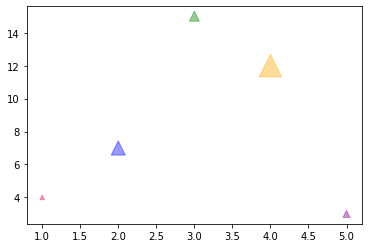

In [8]:
fig, ax = plt.subplots()

ax.scatter(
    [1,2,3,4,5],
    [4,7,15,12,3],
    s=[20,200,100,500,50],
    c=['crimson', 'blue', 'green', 'orange', 'purple'],
    alpha=0.4,
    marker='^'
)

As with ``plot()``, you can use a DataFrame to supply the data.
In this case, the first two arguments should be the column names of the x and y data in the DataFrame.
Any extra columns in the DataFrame are ignored.

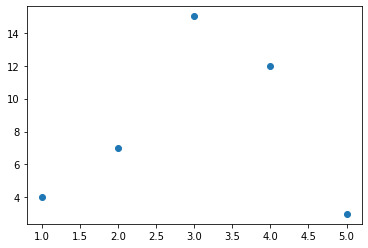

In [9]:
scatter_data = pd.DataFrame({
    "x data": [1,2,3,4,5],
    "y data": [4,7,15,12,3],
    "unused data": [1,1,1,1,1],
})

fig, ax = plt.subplots()
ax.scatter('x data', 'y data', data=scatter_data)

### bar()
The first argument is the x axis, the second argument is the height of the bars. Alternatively, ``barh()`` works similarly to create a horizontal bar plot.

<BarContainer object of 5 artists>

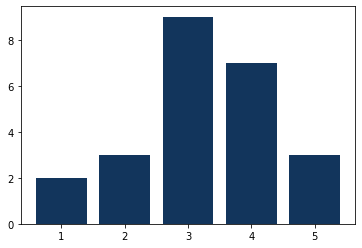

In [10]:
fig, ax = plt.subplots()
ax.bar([1,2,3,4,5], [2,3,9,7,3], color='#12355C')

As before, we can provide data to ``bar()`` by passing in x and y column names with a Pandas DataFrame instead.

By default, calling ``bar()`` multiple times on the same Axes will create overlapping bars.
To create bars side by side, we can tell matplotlib the width of each bar and where to position the middle of it.

<BarContainer object of 5 artists>

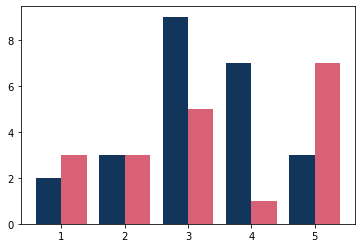

In [11]:
fig, ax = plt.subplots()
x = np.array([1,2,3,4,5])
bar_width = 0.4
ax.bar(x-0.2, [2,3,9,7,3], bar_width, color='#12355C')
ax.bar(x+0.2, [3,3,5,1,7], bar_width, color='#D86175')

The width of the bars can be modified with the ``width`` parameter (either a value for each bar or a single value that is applied to all bars), and the starting height of the bar can be modified with the parameter ``bottom``.
Changing the start height of bars allows us to create stacked bar charts, with different categories of data showing in different colours and stacked one on top of the other.

The spines of an Axes are the four lines forming the outline of the plot area.
The bottom and left spines have the x and y axis drawn on them (by default).
In the example below, the two plots show the same data, but in the right-hand plot the x axis has been made to display in the middle, along the line y=0, by changing the position of the bottom spine.

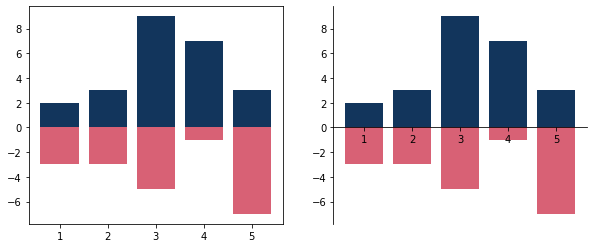

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
x = np.array([1,2,3,4,5])
y1 = [2,3,9,7,3]  # First set of y data
y2 = [-3,-3,-5,-1,-7]  # Second set of y data
axs[0].bar(x, y1, color='#12355C')
axs[0].bar(x, y2, color='#D86175')
# Notice how x is a NumPy array and y is a list
axs[1].bar(x, y1, color='#12355C')
axs[1].bar(x, y2, color='#D86175')
# get the bottom spine and move it to y=0
axs[1].spines['bottom'].set_position('zero')
# remove top and right spines
axs[1].spines['right'].set_color('none')
axs[1].spines['top'].set_color('none')

As usual, there are many more optional arguments to control every aspect of the plot's appearance.
You can find a full list of these in the documentation for the `bar()` method.

### pie()
To make a pie chart, the first parameter gives values for each category (it is assumed that the categories are appropriate for representation as a pie chart), and the parameter `labels` takes a list of the category names.
Optional parameters allow the appearance to be modified; some of these parameters are specified in the following table.

|parameter|value type|meaning|
|---|---|---|
|colors|list|specify a color for each wedge|
|startangle|float|the angle in degrees to start drawing the pie|
|counterclock|Boolean|if true then draw the wedges counter-clockwise|

([<matplotlib.patches.Wedge at 0x218e9614130>,
 [Text(1.04873603504994, -0.3318926464803513, 'these'),
  Text(0.44997552037176547, -1.003753969389989, 'are'),
  Text(-1.0487360350499397, -0.33189264648035166, 'the'),
  Text(0.20943022501311442, 1.0798791510400396, 'pie'),
  Text(1.071064956678631, 0.25063890076163897, 'slices')])

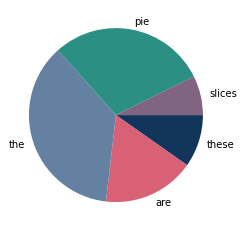

In [13]:
fig, ax = plt.subplots()
ax.pie(
    [4,7,15,12,3],
    labels=["these", "are", "the", "pie", "slices"],
    counterclock=False,
    colors=['#12355C', '#D86175', '#6481A2', '#2B8F84', '#806480']
)

In many of the examples we've seen so far, some text is printed above the plot. This is because the methods used in the last lines of these cells return a tuple of one or more objects that were not assigned to variables, so it is printed to screen. In the example above, the tuple prints quite a lot of text to screen. We might not need the objects returned, so we might want to suppress this output, which we can do by either assigning the output to a dummy (i.e. unused) variable, or by putting a semi-colon, `;`, after the last function call. Try each of these in the cell above.

### stackplot()

A stacked area plot with a single set of (x,y) data is like a line graph, but the area under the curve is filled in.
When multiple values for y are supplied, the values are stacked on top of each other.
This is useful for displaying categories of data, for example, we might show the profit made in each month over different product lines, and by stacking these values on top of each other, we can see the total profit in each month. We may need to use transparency so that all of the areas are visible.

Using a DataFrame to supply the data is similar to previous types of plot, but we can name multiple columns for the y data.

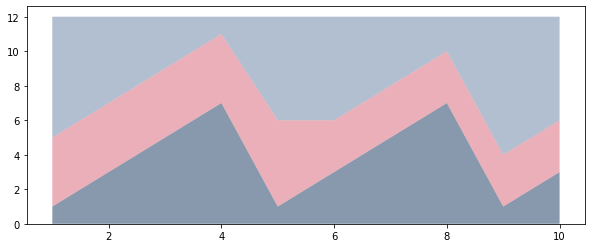

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))
df = pd.DataFrame({
    'x': [1,2,3,4,5,6,7,8,9,10],
    'y1': [1,3,5,7,1,3,5,7,1,3],
    'y2': [4,4,4,4,5,3,3,3,3,3]
})
# add a third data set such that y1+y2+y3 = 12 for all values of x
df['y3'] = 12 - (df['y1']+df['y2'])
ax.stackplot(
    'x',
    'y1',
    'y2',
    'y3',
    data=df,
    colors=['#12355C', '#D86175', '#6481A2'],
    alpha=0.5
)

Note that `stackplot()` adds up the y data. Try making some of the values in the `'y1'` column above negative. How does this affect the shading? 

If you want to fill an area on a graph, bounded by curves and/or the y axis, then a better method than `stackplot()` is `fill_between` – see the matplotlib documentation for more details.

### boxplot()
A box plot summarises the distribution of the data.
The value of the upper and lower quartiles (Q3 and Q1) and the median (Q2) are shown as the 'box' and a line within the box.
Extending beyond the box are 'whiskers' which show the range of the data values.
By default, the whiskers extend no further than Q3+1.5(Q3-Q1) and Q1-1.5(Q3-Q1).
Any values outside of this are shown with dots as outliers.
Because a box plot is a summary of the data, some information is lost, and we can get identical plots despite different underlying data distributions.

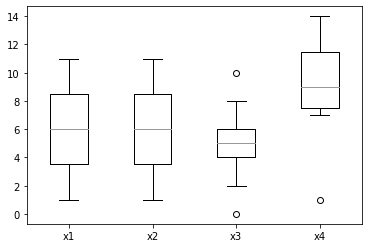

In [15]:
fig, ax = plt.subplots()

data = [
    [1,2,3,4,5,6,7,8,9,10,11],
    [1,1,1,3,4,4,4,6,8,8,8,9,9,11,11],
    [0,2,3,4,5,5,5,5,5,6,7,8,10],
    [1,7,8,9,11,12,14]
]

datalabels = ['x1', 'x2', 'x3', 'x4']

ax.boxplot(data, labels=datalabels); 
# boxplot returns a dictionary with several objects – these have been suppressed above

### hist()

A histogram is one of the most commonly used visualisations for understanding the distribution of numerical data. It divides the range of values into bins (intervals) and counts how many data points fall into each bin. The height of each bar represents the frequency (count) of values in that bin.

Histograms are particularly useful for:
- understanding the shape of a distribution (normal, skewed, bimodal, etc.),
- identifying outliers,
- comparing distributions between different groups,
- exploring data before applying statistical methods

The basic syntax for creating a histogram is `ax.hist(data)`, where `data` is a sequence of values to be binned.


Text(0.5, 1.0, 'Distribution of Sample Data')

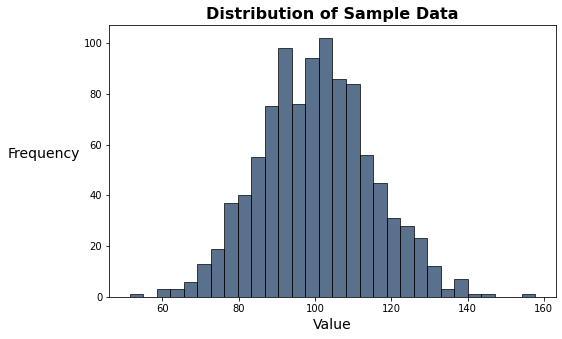

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
# Generate some random data from a normal distribution
np.random.seed(42)
data = np.random.normal(loc=100, scale=15, size=1000)
ax.hist(data, bins=30, color='#12355C', edgecolor='black', alpha=0.7)
ax.set_xlabel('Value', fontsize=14)
ax.set_ylabel('Frequency', fontsize=14, rotation=0, labelpad=40)
ax.set_title('Distribution of Sample Data', fontsize=16, fontweight='bold')

The appearance and information conveyed by a histogram can be controlled using several parameters:

|parameter|value type|meaning|
|---|---|---|
|bins|int or sequence|Number of bins or explicit bin edges|
|edgecolor|color|Color of the bar edges|
|alpha|float (0–1)|Transparency of the bars|
|density|Boolean|If True, normalise to form a probability density|
|color|color|Color of the bars|
|orientation|'vertical' or 'horizontal'|Orientation of the bars|

The choice of the number of bins is important, too few bins may hide important features of the distribution, while too many bins can create a noisy, hard-to-interpret plot. A common rule of thumb is to use the square root of the number of data points. Matplotlib does not apply such a rule automatically — it defaults to 10 bins — but passing bins='auto' selects the number of bins adaptively (the larger of the Sturges and Freedman–Diaconis estimates).

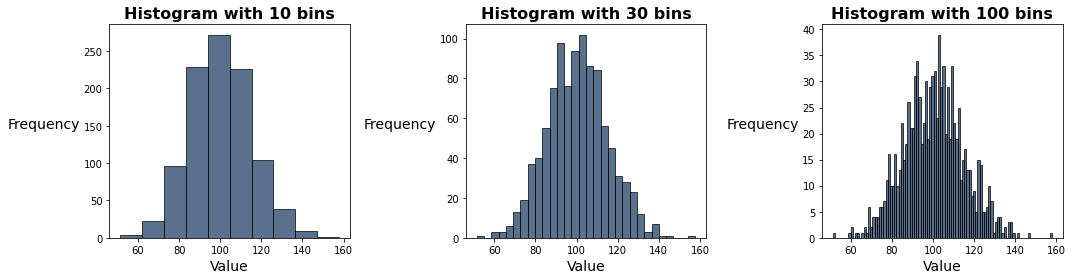

In [ ]:
# Comparing Different Numbers of Bins
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
# Same data, different bin counts
bin_counts = [10, 30, 100] 
for ax, bins in zip(axs, bin_counts):
    ax.hist(data, bins=bins, edgecolor='black', alpha=0.7, color='#12355C')
    ax.set_xlabel('Value', fontsize=14)
    ax.set_ylabel('Frequency', fontsize=14, rotation=0, labelpad=40)
    ax.set_title(f'Histogram with {bins} bins', fontsize=16, fontweight='bold')
fig.tight_layout()

## Normalised Histograms


Sometimes we want to compare distributions from datasets with different sizes. In such cases, it's useful to normalise the histogram so that the total area equals 1, forming a probability density. This is achieved using the `density=True` parameter.


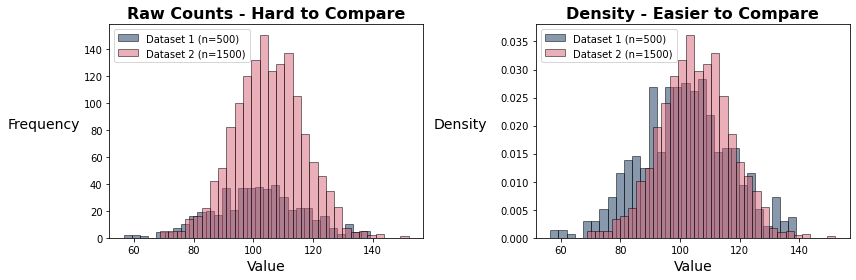

In [18]:
# density histograms
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
# Two datasets with different sizes
data1 = np.random.normal(loc=100, scale=15, size=500)
data2 = np.random.normal(loc=105, scale=12, size=1500)
# Raw counts
axs[0].hist(data1, bins=30, alpha=0.5, label='Dataset 1 (n=500)', color='#12355C', edgecolor='black')
axs[0].hist(data2, bins=30, alpha=0.5, label='Dataset 2 (n=1500)', color='#D86175', edgecolor='black')
axs[0].set_xlabel('Value', fontsize=14)
axs[0].set_ylabel('Frequency', fontsize=14, rotation=0, labelpad=40)
axs[0].set_title('Raw Counts - Hard to Compare', fontsize=16, fontweight='bold')
axs[0].legend()
# Density (normalized)
axs[1].hist(data1, bins=30, alpha=0.5, label='Dataset 1 (n=500)', color='#12355C', edgecolor='black', density=True)
axs[1].hist(data2, bins=30, alpha=0.5, label='Dataset 2 (n=1500)', color='#D86175', edgecolor='black', density=True)
axs[1].set_xlabel('Value', fontsize=14)
axs[1].set_ylabel('Density', fontsize=14, rotation=0, labelpad=40)
axs[1].set_title('Density - Easier to Compare', fontsize=16, fontweight='bold')
axs[1].legend()
fig.tight_layout()

## Kernel density estimation (KDE)

While histograms are intuitive and easy to create, they have some limitations:
- The appearance depends heavily on the choice of bin width and bin edges.
- They can appear 'blocky' or discontinuous.
- Small changes in bin placement can significantly change the visual impression.

**Kernel density estimation (KDE)** provides a smoothed alternative to histograms. Instead of sorting data into discrete bins, KDE estimates the probability density function by placing a smooth "kernel" (typically a Gaussian/normal curve) at each data point and summing these up. The result is a smooth curve that represents the distribution.

KDE is particularly useful when:
- you want a smooth representation of the distribution,
- you are presenting to audiences who might find smooth curves more intuitive,
- you want to avoid the arbitrary nature of bin placement.

The smoothness of the KDE curve is controlled by the **bandwidth** parameter – larger bandwidth creates smoother curves but may hide important features, while smaller bandwidth preserves more detail but can be noisy.

To create KDE plots in Matplotlib, we can use `scipy.stats.gaussian_kde` to calculate the density, then plot it with a line plot. Alternatively, we can use seaborn (which is built on top of matplotlib) for a simpler interface.


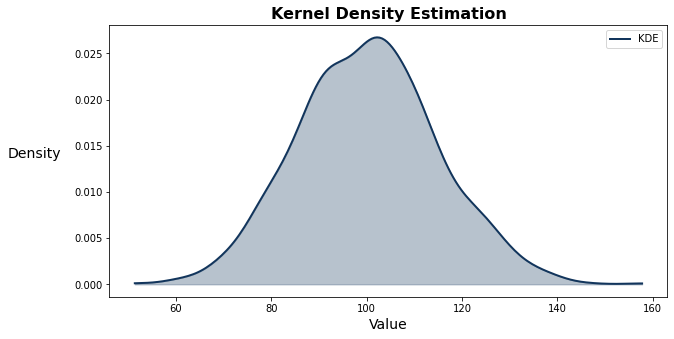

In [19]:
# Basic KDE Plot
from scipy import stats
fig, ax = plt.subplots(figsize=(10, 5))
# Create a KDE from the data
kde = stats.gaussian_kde(data)
# Create a range of x values for plotting the KDE
x_range = np.linspace(data.min(), data.max(), 200)
# Evaluate the KDE at each point
density = kde(x_range)
# Plot the KDE
ax.plot(x_range, density, linewidth=2, label='KDE', color='#12355C')
ax.fill_between(x_range, density, alpha=0.3, color='#12355C')
ax.set_xlabel('Value', fontsize=14)
ax.set_ylabel('Density', fontsize=14, rotation=0, labelpad=40)
ax.set_title('Kernel Density Estimation', fontsize=16, fontweight='bold')
ax.legend()

It's often informative to plot both a histogram and KDE together to see how they complement each other. The histogram shows the actual binned data, while the KDE provides a smooth interpretation of the underlying distribution.


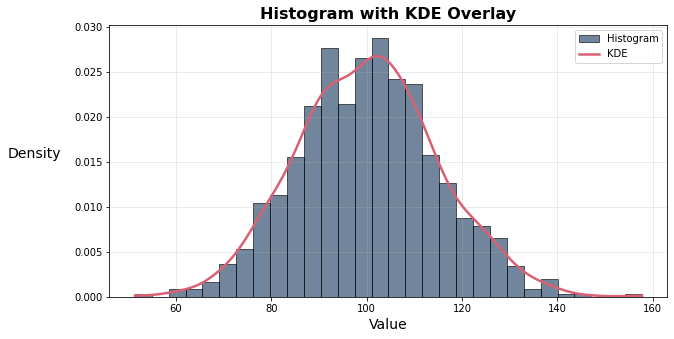

In [20]:
# Histogram + KDE Overlay
fig, ax = plt.subplots(figsize=(10, 5))
# Plot normalized histogram
ax.hist(data, bins=30, density=True, alpha=0.6, color='#12355C', edgecolor='black', label='Histogram')
# Overlay KDE
kde = stats.gaussian_kde(data)
x_range = np.linspace(data.min(), data.max(), 200)
ax.plot(x_range, kde(x_range), linewidth=2.5, color='#D86175', label='KDE')
ax.set_xlabel('Value', fontsize=14)
ax.set_ylabel('Density', fontsize=14, rotation=0, labelpad=40)
ax.set_title('Histogram with KDE Overlay', fontsize=16, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)